# Optimal stopping: preliminary numerical validation

This notebook checks the analytical reference and inspects the saved numerical refinement experiment. It is an entry point to the Stage 1 prototype, not a completed empirical study.

The inputs are declared mathematical test fixtures. Simulated paths and model prices are not observed market data. The aim is to verify the baseline and understand the limits of the numerical comparisons.

1. Load the recorded configuration and reference.
2. Recompute the European analytical value through the source package.
3. Inspect saved refinement errors and their interpretation.

Methods and attribution: [source register](../SOURCES.md), [theory](../theory.md) and [full validation record](../results/baseline/findings.md). Install the repository and its notebook dependencies before running.

In [1]:
from pathlib import Path
import json

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
import csv
import math
import matplotlib.pyplot as plt
from qf_research.optimal_stopping.analytical import black_scholes
from qf_research.optimal_stopping.contracts import Market, Option

project = ROOT / "projects/01_optimal_stopping"
config = json.loads((project / "configs/benchmark.json").read_text())
manifest = json.loads((project / "results/baseline/manifest.json").read_text())
print(config["purpose"])
print(config["input_origin"])
print("Recorded seed:", config["seed"])


numerical_validation_only
Analytically specified test fixture; not observed market data
Recorded seed: 20260914


## Analytical reference

The saved put contract has constant coefficients. Recomputing the analytical value provides a deterministic baseline before interpreting the discretised early-exercise methods. This check uses no new random samples.

In [2]:
market = Market(**config["market"])
option = Option(**config["option"])
value = black_scholes(market, option)
reference = manifest["references"]["european_analytical"]
assert math.isclose(value, reference, rel_tol=1e-12, abs_tol=1e-12)
print(f"Recomputed European value: {value:.10f}")
print(f"Saved European reference: {reference:.10f}")
print("Agreement within the stated numerical tolerance.")


Recomputed European value: 5.5735260223
Saved European reference: 5.5735260223
Agreement within the stated numerical tolerance.


## Saved refinement experiment

These values come from the recorded benchmark run. The next cell reads its output, rather than rerunning the whole experiment. European errors are measured against the analytical solution. Bermudan differences use a fine PDE reference, which is itself a numerical approximation.

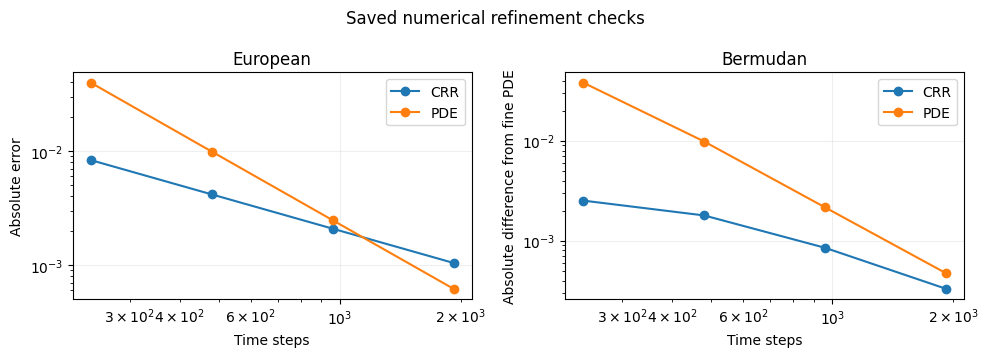

In [3]:
with (project / "results/baseline/grid_convergence.csv").open(newline="") as stream:
    rows = list(csv.DictReader(stream))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, contract in zip(axes, ["European", "Bermudan"]):
    for method in ["CRR", "PDE"]:
        selected = [r for r in rows if r["contract"] == contract and r["method"] == method]
        ax.loglog([int(r["time_steps"]) for r in selected],
                  [abs(float(r["error"])) for r in selected], marker="o", label=method)
    ax.set_title(contract)
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Absolute error" if contract == "European" else "Absolute difference from fine PDE")
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle("Saved numerical refinement checks")
fig.tight_layout()
plt.show()


## Interpretation and next checks

Agreement across numerical methods is evidence of consistency, not a certified bound on the optimal value. The PDE sequence changes both time and space resolution, so its plotted slope does not isolate an order of convergence in time. CRR space resolution is determined by its time grid.

A useful next check is to hold the PDE spatial grid fixed while refining time, then reverse the experiment. Record the resulting configuration and new output directory before comparing results. The full research design also requires stress cases, credible policy-loss measurement and observed option quotes.

The current notebook establishes a reproducible numerical starting point. It makes no finding about actual option-market efficiency or investment performance.